In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import numpy as np

In [2]:
data_path = "../../data/EuroSAT_RGB"
classes = sorted(os.listdir(data_path))

In [3]:
stats = []
for cls in classes:
    count = len(os.listdir(os.path.join(data_path, cls)))
    stats.append({"Class": cls, "Count": count})

df = pd.DataFrame(stats)

In [4]:
df

,Class,Count
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


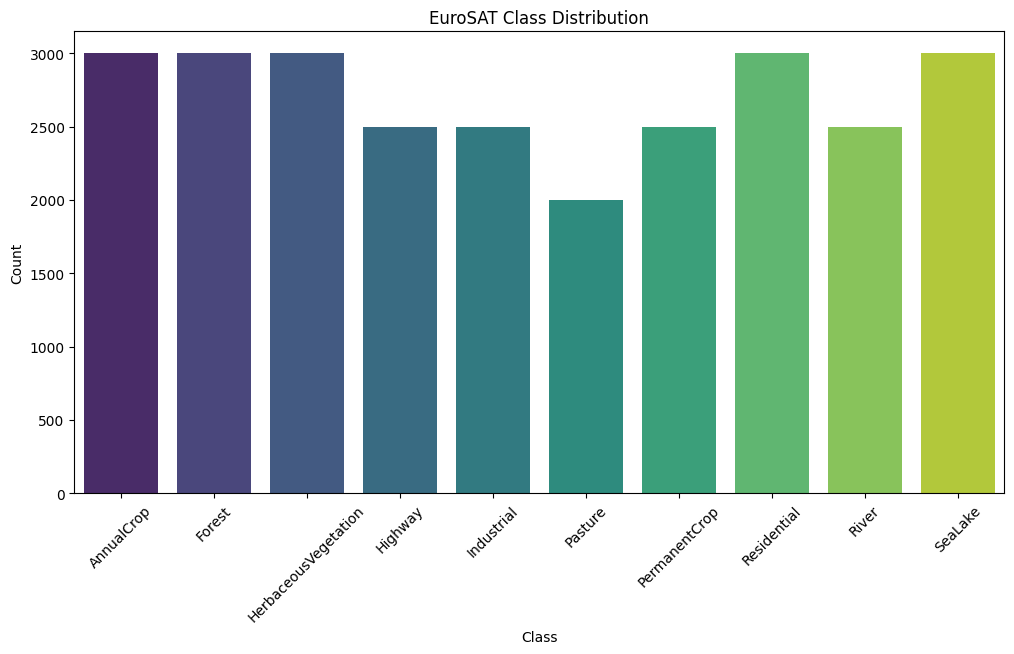

In [9]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Class", y="Count", palette="viridis", hue="Class")
plt.xticks(rotation=45)
plt.title("EuroSAT Class Distribution")
plt.show()


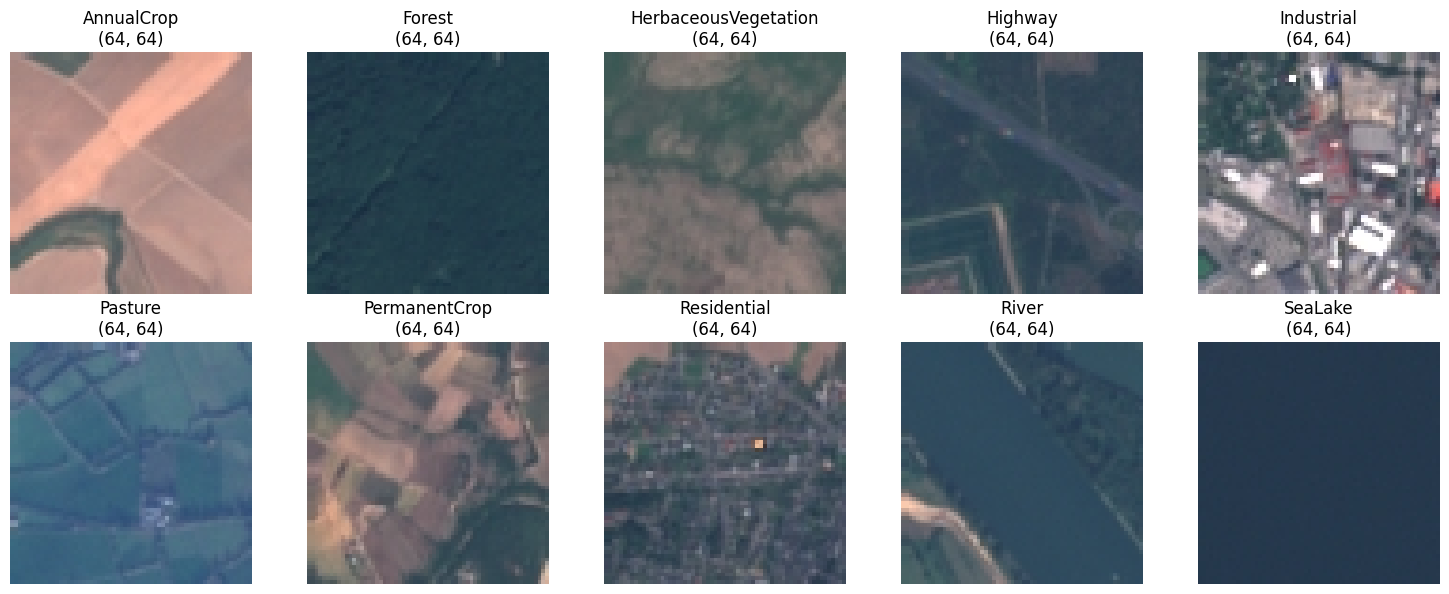

In [10]:
def plot_samples(data_path, classes, samples_per_class=1):
    plt.figure(figsize=(15, 6))
    for i, cls in enumerate(classes):
        cls_path = os.path.join(data_path, cls)
        img_name = os.listdir(cls_path)[0]
        img_path = os.path.join(cls_path, img_name)
        
        img = Image.open(img_path)
        
        plt.subplot(2, 5, i + 1)
        plt.imshow(img)
        plt.title(f"{cls}\n{img.size}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

plot_samples(data_path, classes)

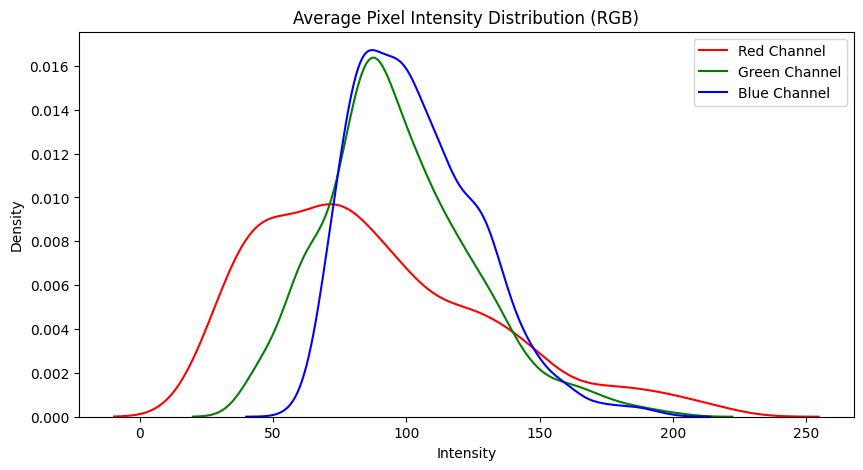

In [12]:
def plot_color_distribution(data_path, classes, num_samples=100):
    reds, greens, blues = [], [], []
    
    for cls in classes:
        cls_path = os.path.join(data_path, cls)
        images = os.listdir(cls_path)[:num_samples]
        for img_name in images:
            img = Image.open(os.path.join(cls_path, img_name))
            img_array = np.array(img) 
            reds.append(np.mean(img_array[:,:,0]))
            greens.append(np.mean(img_array[:,:,1]))
            blues.append(np.mean(img_array[:,:,2]))

    plt.figure(figsize=(10, 5))
    sns.kdeplot(reds, color="red", label="Red Channel")
    sns.kdeplot(greens, color="green", label="Green Channel")
    sns.kdeplot(blues, color="blue", label="Blue Channel")
    plt.title("Average Pixel Intensity Distribution (RGB)")
    plt.xlabel("Intensity")
    plt.legend()
    plt.show()

plot_color_distribution(data_path, classes)